[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_4/04B-RandomForests.ipynb)

# 04B — Random Forests

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 4, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`04A` ended on a problem rather than a result. Three bootstrap resamples of the same 150 flowers
gave three different trees — different questions, different thresholds, different partitions of the
plane. A single tree is a **low-bias, high-variance** model in exactly `03B`'s sense: it can
represent almost anything, and it changes a great deal when the data change a little.

`03B` also gave the standard cure for variance, and its third exercise had you build it by hand:
**average many independent estimates**. This notebook applies that to trees, finds that the obvious
version is not quite enough, and fixes it with one further idea. The result is not quite the best
model in this course for tabular scientific data — `04C`'s boosting usually edges it — but it comes
close, it is markedly easier to tune, and it is the one to reach for first.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain **bagging** — bootstrap the data, fit a model to each resample, aggregate the answers —
  and why it reduces variance without increasing bias;
- say why a bootstrap resample is drawn **with replacement** and at full size, and why the folds of
  cross-validation are not a substitute;
- say why bagged trees are still too similar to each other, and measure how similar;
- explain the **random subspace** trick that makes a bagging ensemble a **random forest**, and what
  `max_features` controls;
- choose `n_estimators`, and explain why more trees never overfits while more depth does;
- use the **out-of-bag** score as validation that costs nothing;
- read a **feature importance** and name the three ways it misleads;
- say why a forest's probabilities are better behaved than a tree's and still not
  calibrated.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                     train_test_split, RepeatedStratifiedKFold)
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)

# 1. One tree is a noisy estimate

The iris flowers of `04A` were convenient for drawing but too easy to argue with. This notebook uses
a harder and more typical dataset: **569 breast tumour samples**, each described by thirty
measurements taken from a digitised image of a fine-needle aspirate — radius, texture, perimeter,
area, concavity and so on, each reported as a mean, a standard error and a "worst" value. The task
is to classify the sample as malignant or benign.

Thirty features and a few hundred samples is the shape of an enormous amount of scientific data,
and it is the shape trees are good at.

The first cell fits fifty trees, each to a different **bootstrap resample** of the same training
set — 398 patients drawn from those same 398 with replacement, as in `04A` §11.3. Section 2 says
what the bootstrap is and why it is the right tool here; for the moment it is only a way of
producing fifty slightly different training sets out of one. The question the cell asks is how much
the fifty trees disagree.

In [2]:
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

resample = np.random.default_rng(0)
predictions = []
for _ in range(50):
    rows = resample.integers(0, len(y_train), len(y_train))
    tree = DecisionTreeClassifier(random_state=0).fit(X_train.iloc[rows], y_train.iloc[rows])
    predictions.append(tree.predict(X_test))
predictions = np.array(predictions)

accuracies = (predictions == y_test.to_numpy()).mean(axis=1)
share_benign = predictions.mean(axis=0)
contested = (share_benign > 0) & (share_benign < 1)

print(f"{len(y)} samples, {X.shape[1]} measurements each")
print(f"\nfifty trees, each on its own resample of the same training data:")
print(f"   accuracy on the test set:  worst {accuracies.min():.3f}"
      f"   best {accuracies.max():.3f}   spread {accuracies.max() - accuracies.min():.3f}")
print(f"   test samples the fifty trees do not all agree about: "
      f"{contested.sum()} of {len(y_test)}")

569 samples, 30 measurements each

fifty trees, each on its own resample of the same training data:
   accuracy on the test set:  worst 0.883   best 0.947   spread 0.064
   test samples the fifty trees do not all agree about: 51 of 171


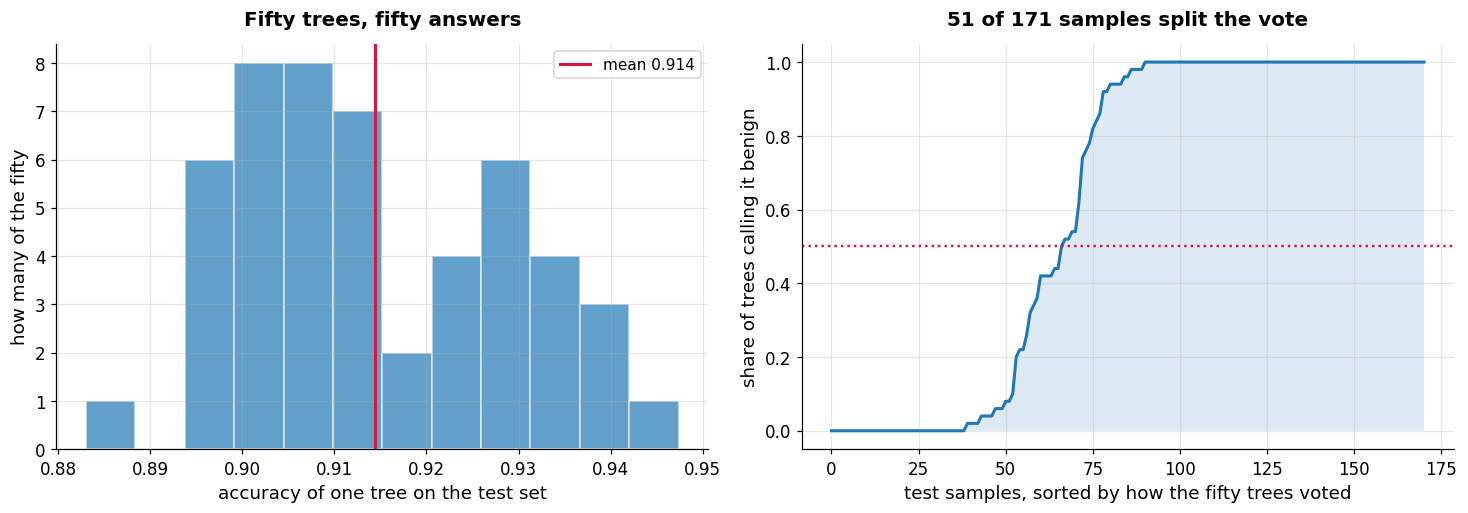

In [3]:
fig, (spread, votes) = plt.subplots(1, 2, figsize=(13.5, 4.8))

spread.hist(accuracies, bins=12, color="tab:blue", alpha=0.7, edgecolor="white")
spread.axvline(accuracies.mean(), color="crimson", linewidth=2,
               label=f"mean {accuracies.mean():.3f}")
spread.set_xlabel("accuracy of one tree on the test set")
spread.set_ylabel("how many of the fifty")
spread.set_title("Fifty trees, fifty answers")
spread.legend()

order = np.argsort(share_benign)
votes.plot(np.arange(len(y_test)), share_benign[order], linewidth=2)
votes.fill_between(np.arange(len(y_test)), 0, share_benign[order], alpha=0.15)
votes.axhline(0.5, color="crimson", linestyle=":", linewidth=1.6)
votes.set_xlabel("test samples, sorted by how the fifty trees voted")
votes.set_ylabel("share of trees calling it benign")
votes.set_title(f"{contested.sum()} of {len(y_test)} samples split the vote")
plt.show()

Two readings, one per panel.

**No tree is the tree.** The fifty differ by several points of accuracy, and nothing distinguishes
the best from the worst except which bootstrap sample it happened to see. Reporting any one of them
as *the* result would be reporting an accident.

**But they do not disagree everywhere.** The right-hand panel sorts the test samples by how the vote
went. At both ends the curve is flat: for most samples all fifty trees say the same thing, and those
are the easy ones. The disagreement is concentrated in the middle — the samples near the boundary,
where a slightly different tree draws the line on the other side.

That shape is the opportunity. If the trees were wrong in the *same* way there would be nothing to
gain by combining them. They are wrong in *different* ways, and different errors can cancel.

# 2. Bagging: bootstrap, then aggregate

`03B` §7 established the rule this rests on. Averaging $B$ independent estimates leaves the bias
where it was and divides the variance by $B$:

$$
\operatorname{Var}\Bigl[\tfrac{1}{B}\textstyle\sum_b \hat{f}_b\Bigr]
\;=\; \frac{\sigma^2}{B}
\qquad\text{when the } \hat{f}_b \text{ are independent.}
$$

A tree is a low-bias, high-variance estimator, so it is exactly the thing this helps most: there is
little bias to be stuck with, and a great deal of variance to divide.

The obstacle is that we have one dataset, not $B$ of them. Manufacturing the missing ones is what
the **bootstrap** does, and `03C` §4 and `04A` §11.3 have both already borrowed it. Here it stops
being a convenience and becomes the method, so it is worth stating properly.

### The bootstrap

We want to know what a quantity would do if the experiment were repeated. The honest way is to
repeat it, and we cannot: the 398 patients are all there are.

The bootstrap's answer starts from what the experiment *was*. The 398 patients are $n$ independent
draws from some population of tumours. We cannot draw from that population again — but we hold the
best estimate of it that exists, which is the sample itself: 398 patients, each carrying weight
$1/398$.

So **re-run the experiment against that stand-in.** Draw $n$ observations, independently, from the
training set. That is a bootstrap resample, and its whole design is an imitation of how the real
dataset was produced — same number of draws, drawn the same way.

**Independently** is the word that forces *with replacement*. If each draw is made from the whole
set, an observation already taken can be taken again, and the draws do not affect one another: every
one is a fresh pick from the same distribution. Remove an observation once drawn and the draws
become dependent — the second is a pick from a different, smaller distribution than the first — and
the resample is no longer $n$ independent observations from anything.

Be careful about which independence that is. It is independence **within** one resample — between
the $n$ draws that make it up. Whether two *different* resamples are independent **of each other**
is a separate question and a more delicate one, and section 3 is about what the answer costs.

The degenerate case makes it concrete. Drawing $n$ *without* replacement returns the same $n$
observations in a different order: one dataset, not many, and no variability at all. Drawing with
replacement returns a set of the same size in which some observations appear twice or three times,
some once, and some not at all.

Two consequences matter later. A resample is the same size as the original, so nothing has to be set
aside to make one. And a substantial share of the original observations is missing from any given
resample — section 6 measures that share and finds a use for it.

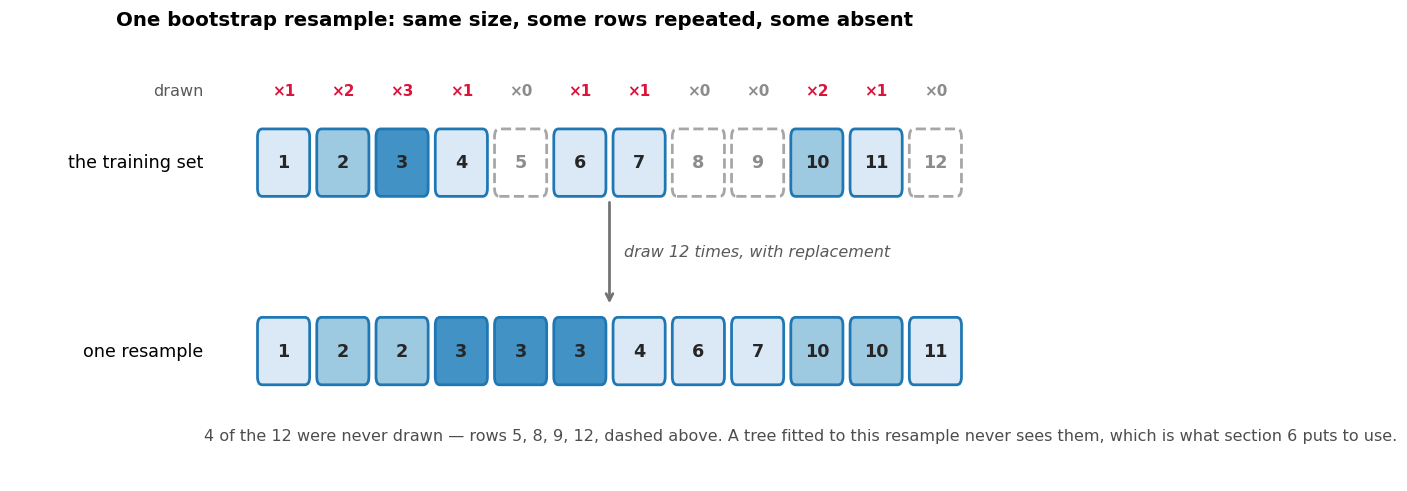

In [ ]:
# One bootstrap resample of a small training set, drawn so the mechanics are visible.
# Twelve rows rather than 398, for the same reason every diagram in this course uses few points.

show = np.random.default_rng(3)
n_show = 12
drawn = np.sort(show.integers(0, n_show, n_show))       # 12 draws, with replacement
times_drawn = np.bincount(drawn, minlength=n_show)

fig, axis = plt.subplots(figsize=(12.5, 4.6))
box_w, box_h = 0.82, 0.62
shades = {0: "white", 1: "#dbe9f6", 2: "#9ecae1", 3: "#4292c6"}

def box(x, y, label, face, edge, text_colour="0.15", dashed=False):
    axis.add_patch(FancyBboxPatch((x - box_w / 2, y - box_h / 2), box_w, box_h,
                                  boxstyle="round,pad=0.03,rounding_size=0.08",
                                  facecolor=face, edgecolor=edge, linewidth=1.8,
                                  linestyle="--" if dashed else "-", zorder=2))
    axis.text(x, y, label, ha="center", va="center", fontsize=11.5, zorder=4,
              fontweight="bold", color=text_colour)

for i in range(n_show):                                  # the training set, shaded by draw count
    out = times_drawn[i] == 0
    box(i, 1.5, str(i + 1), shades[times_drawn[i]],
        "0.65" if out else "tab:blue", "0.55" if out else "0.15", dashed=out)
    axis.text(i, 2.22, f"×{times_drawn[i]}", ha="center", va="center", fontsize=10,
              color="0.55" if out else "crimson", fontweight="bold")

for slot, source in enumerate(drawn):                    # the resample itself
    box(slot, -0.4, str(source + 1), shades[min(times_drawn[source], 3)], "tab:blue")

axis.text(-1.35, 2.22, "drawn", ha="right", va="center", fontsize=10.5, color="0.35")
axis.text(-1.35, 1.5, "the training set", ha="right", va="center", fontsize=11.5)
axis.text(-1.35, -0.4, "one resample", ha="right", va="center", fontsize=11.5)

axis.annotate("", xy=(5.5, 0.05), xytext=(5.5, 1.13),
              arrowprops={"arrowstyle": "->", "linewidth": 1.8, "color": "0.45"})
axis.text(5.75, 0.6, "draw 12 times, with replacement", fontsize=10.5,
          style="italic", color="0.35", va="center")

never = np.flatnonzero(times_drawn == 0)
axis.text(-1.35, -1.25,
          f"{len(never)} of the {n_show} were never drawn — rows "
          f"{', '.join(str(i + 1) for i in never)}, dashed above. A tree fitted to this resample "
          f"never sees them, which is what section 6 puts to use.",
          ha="left", va="center", fontsize=10.5, color="0.3")

axis.set_xlim(-4.6, n_show + 0.4)
axis.set_ylim(-1.7, 2.7)
axis.axis("off")
axis.set_title("One bootstrap resample: same size, some rows repeated, some absent")
plt.show()

Read the figure as one draw. Row 3 was picked three times and appears three times in the resample;
rows 5, 8, 9 and 12 were picked not at all and are absent from it. The resample still has twelve
rows, and it is not the training set.

Do that $B$ times, fit a tree to each, and aggregate the answers — bootstrap, then aggregate, which
is **bagging**. `BaggingClassifier` does both.

**"Aggregate" means whatever the task means.** For a classifier the trees vote and the majority
wins; for a regressor their predicted numbers are averaged. Nothing else changes — same bootstrap,
same trees, same argument about variance — which is `04A` §10's point that one algorithm covers both
tasks, carried into the ensemble. `RandomForestRegressor` and `BaggingRegressor` are the
counterparts of the two classes used below, and everything in this notebook applies to them.

In [ ]:
# Is a bootstrap resample really a stand-in for re-running the experiment? Here we can check,
# because we can cheat: treat all 569 tumour samples as the population, and actually re-run.

population = cancer.data["worst perimeter"].to_numpy()
draw = np.random.default_rng(0)
experiment_size = 120

# The truth: run the experiment 4000 times and watch how much the median moves.
truth = np.std([np.median(draw.choice(population, experiment_size, replace=False))
                for _ in range(4000)])

# What a scientist actually has: one experiment. Estimate that spread from it alone.
one_experiment = draw.choice(population, experiment_size, replace=False)

def estimated_spread(size, replace):
    return np.std([np.median(draw.choice(one_experiment, size, replace=replace))
                   for _ in range(4000)])

print(f"how much the median of 'worst perimeter' moves between experiments of {experiment_size}\n")
print(f"{'':52}{'spread':>9}{'vs truth':>10}")
print(f"{'the truth, from re-running the experiment 4000 times':52}{truth:>9.3f}{1.0:>10.2f}")
for label, size, replace in [
        ("bootstrap: n draws, with replacement", experiment_size, True),
        ("n draws, without replacement", experiment_size, False),
        ("n/4 draws, without replacement", experiment_size // 4, False)]:
    spread = estimated_spread(size, replace)
    print(f"{label:52}{spread:>9.3f}{spread / truth:>10.2f}")

how much the median of 'worst perimeter' moves between experiments of 120

                                                       spread  vs truth
the truth, from re-running the experiment 4000 times    2.756      1.00
bootstrap: n draws, with replacement                    2.698      0.98
n draws, without replacement                            0.000      0.00
n/4 draws, without replacement                          4.554      1.65


The bootstrap lands on the truth without ever being told it, from a single experiment of 120.

The second row is the degenerate case: draw all $n$ without replacement and every resample is the
same 120 numbers, so the median never moves and the estimated spread is exactly zero. Taking fewer
than $n$ does restore some variability, but not the variability that was asked about: the third row
overstates it by about two thirds, and how far it is out depends on how many were drawn. Recovering
an answer about an experiment of 120 from it takes a correction. The bootstrap needs none, because
it never changed the size of the experiment in the first place.

> Sampling a fraction without replacement is a real technique with its own theory, and the
> correction is known. It is not wrong; it is a different tool. The bootstrap is the one that
> answers the question as asked.

### Why not the folds of `02C`?

Cross-validation also makes many datasets out of one, so it is worth saying why it is not the tool
here. The two are built for different jobs, and this notebook uses both.

**k-fold partitions.** It cuts the data into $k$ parts and holds each out in turn, so that every
observation is tested exactly once. That coverage is what makes it a good way to *score* a
procedure, and it is why `cross_val_score` appears throughout this notebook.

**The bootstrap re-runs.** Each resample is a full-size stand-in for the original experiment, drawn
independently of every other one. That is what an ensemble member needs.

Three differences follow, all of them fatal to using folds for bagging.

- **You get $k$ members and no more.** Bagging wants hundreds; section 5's curve is still climbing
  steeply at 3 and 10 trees. A partition into 200 parts is not an option — each training set would
  be the whole dataset bar a handful of rows, and the members would be identical.
- **Every fold model is trained on less data**, a fraction $1 - 1/k$ of it. The ensemble members
  would each be worse than the model you are trying to build.
- **The folds are constrained by the partition**, not drawn independently: every observation appears
  in exactly $k-1$ of the $k$ training sets, by construction. The bootstrap's resamples are
  independent of one another, which is the condition `03B` §7's variance argument actually needs.

Section 6 adds a fourth: the bootstrap leaves each tree its own held-out set for free, which is a
gift the partition cannot give without becoming cross-validation again.

### Then why is k-fold sound for scoring?

That argument should be uncomfortable. If the bootstrap needs $n$ *independent* draws to be a fair
stand-in for the experiment, and the folds are neither independent of one another nor full-size,
how is a cross-validated score — every number reported in this notebook — trustworthy?

The answer is that the objection applies to a different part of the procedure than it first appears
to, and it is worth taking in three steps.

**One fold, on its own, is completely honest.** Split $n$ i.i.d. observations into two groups by a
rule that never looks at their *values* — a random partition does exactly this — and the two groups
are independent of each other, and each is still an i.i.d. sample from the same population. So the
model trained on $k-1$ folds and the fold it is scored on are as independent as a model and a
genuinely fresh dataset. This is `02C`'s single train/test split, and it needs no further defence.
The cell below checks it against tumours that were never in the study at all.

**What is smaller is the training set, not the population.** Each fold model sees $n(1 - 1/k)$
observations, so cross-validation estimates the error of a model trained on slightly less data than
the one you will finally ship. That is a mild pessimism in *what is being estimated*, and it is why
larger $k$ gives less pessimistic scores. It is not a distortion of any distribution.

**The dependence is real, and it lands on the error bar rather than the estimate.** The $k$ training
sets do overlap — any two of them share a fraction $(k-2)/(k-1)$ of their rows, three quarters of
them at $k = 5$ — so the $k$ scores are correlated. But an average of correlated terms is still an
unbiased estimate of what each term estimates, because expectation is linear whether or not the
terms are independent. What correlation destroys is the *variance* of that average: it is not
$\sigma^2/k$, and `std / sqrt(k)` is therefore not its standard error.

**That is exactly section 3's distinction, met from the other side.** There, correlation between
bagged trees left a floor of $\rho\sigma^2$ that no number of trees could beat. The same algebra
applies here — and the difference is what the average is *for*. Bagging averages in order to
**reduce variance**, so correlation costs it accuracy. Cross-validation averages in order to
**estimate a quantity**, so correlation costs it only the ability to put an honest interval on the
answer. Unbiasedness survives correlation; variance reduction does not.

scored on 40 held out of the same study : 0.9133
scored on 40 tumours from outside it    : 0.9193

the cross-validated estimate actually moves by : 0.0147
the reported std/sqrt(k) error bar says        : 0.0075
the error bar is too small by a factor of 2.0


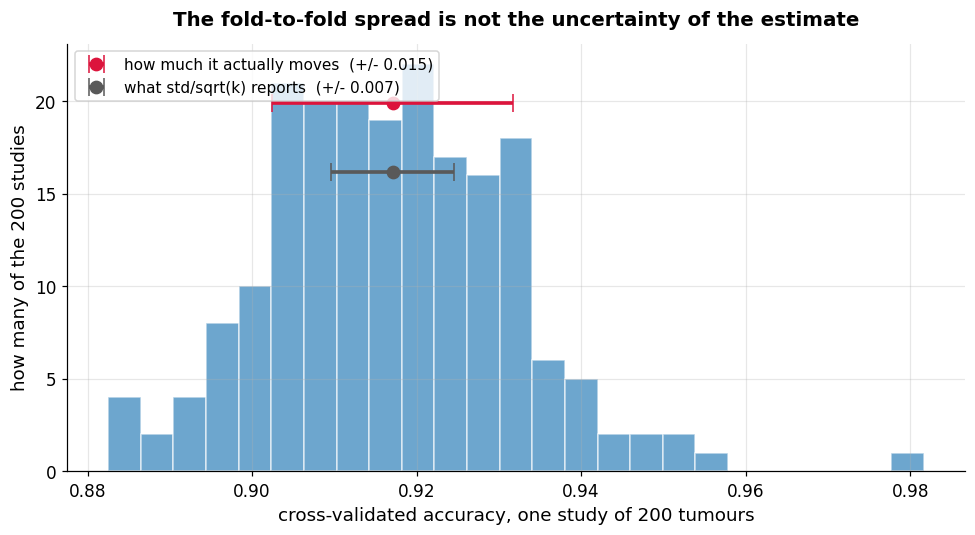

In [ ]:
# Two checks on the paragraphs above, both of which we can run because all 569 tumours are
# available: they let us treat 200 of them as "the study" and the rest as the wider world.

pool_X, pool_y = X.to_numpy(), y.to_numpy()
audit = np.random.default_rng(0)
study_size = 200

# (a) Is one fold honest? Score a tree on the 40 held out of its own study, and on 40 tumours
#     that were never in that study at all. If a fold is honest, the two agree.
held_out, never_seen = [], []
for _ in range(300):
    study = audit.choice(len(pool_y), study_size, replace=False)
    outside = audit.choice(np.setdiff1d(np.arange(len(pool_y)), study), 40, replace=False)
    tree = DecisionTreeClassifier(random_state=0).fit(pool_X[study[:160]], pool_y[study[:160]])
    held_out.append(tree.score(pool_X[study[160:]], pool_y[study[160:]]))
    never_seen.append(tree.score(pool_X[outside], pool_y[outside]))

print(f"scored on 40 held out of the same study : {np.mean(held_out):.4f}")
print(f"scored on 40 tumours from outside it    : {np.mean(never_seen):.4f}")

# (b) Does std/sqrt(k) say how far the estimate is from the truth? Run 200 whole studies and
#     watch how much the cross-validated number itself moves between them.
estimates, reported = [], []
for _ in range(200):
    study = audit.choice(len(pool_y), study_size, replace=False)
    scores = cross_val_score(DecisionTreeClassifier(random_state=0),
                             pool_X[study], pool_y[study], cv=subsets)
    estimates.append(scores.mean())
    reported.append(scores.std() / np.sqrt(len(scores)))

actually_moves, error_bar = np.std(estimates), np.mean(reported)
print(f"\nthe cross-validated estimate actually moves by : {actually_moves:.4f}")
print(f"the reported std/sqrt(k) error bar says        : {error_bar:.4f}")
print(f"the error bar is too small by a factor of {actually_moves / error_bar:.1f}")

fig, axis = plt.subplots(figsize=(9, 5))
axis.hist(estimates, bins=25, color="tab:blue", alpha=0.65, edgecolor="white")
middle, top = np.mean(estimates), axis.get_ylim()[1]
axis.errorbar([middle], [top * 0.86], xerr=[actually_moves], fmt="o", color="crimson",
              capsize=6, linewidth=2.4, markersize=8,
              label=f"how much it actually moves  (+/- {actually_moves:.3f})")
axis.errorbar([middle], [top * 0.70], xerr=[error_bar], fmt="o", color="0.35",
              capsize=6, linewidth=2.4, markersize=8,
              label=f"what std/sqrt(k) reports  (+/- {error_bar:.3f})")
axis.set_xlabel("cross-validated accuracy, one study of 200 tumours")
axis.set_ylabel("how many of the 200 studies")
axis.set_title("The fold-to-fold spread is not the uncertainty of the estimate")
axis.legend(loc="upper left")
plt.show()

Both paragraphs check out.

**The fold is honest.** A tree scores 0.913 on the forty tumours held out of its own study and 0.919
on forty it could never have seen — the same number, to within the noise of three hundred repeats.
Holding data out of a sample really does stand in for data from outside it, provided the holding-out
ignored the values.

**The error bar is not.** The cross-validated estimate moves between studies about **twice** as much
as `std / sqrt(k)` claims. The red bar is the honest one; the grey bar is what the notebook prints.

> **So read every error bar in this notebook as a lower bound.** The means are sound and the
> comparisons between them are the point; the intervals beside them are narrower than the truth,
> here by about a factor of two. That is a property of cross-validation, not of forests, and it is
> why section 4 declines to tune `max_features` hard on a difference of a few thousandths.

One caveat carries over from `02C` §6.2, and it is the case where the first paragraph fails. All of
this assumed the partition ignores the values — which stops being true when the rows are not
independent to begin with. Three visits from one patient, or measurements ordered in time, split
randomly, put a row's near-twin on the other side of the partition, and then the fold is not
independent of its training set at all. The fix is the one `02C` gave: split by patient, or by time,
not by row.

                                    accuracy   std error
breast cancer:
                     a single tree    0.9274      0.0035
                bagging, 200 trees    0.9564      0.0039
               bought by averaging      2.9 pp   (+/- 0.5)

iris petals (04A):
                     a single tree    0.9456      0.0081
                bagging, 200 trees    0.9567      0.0082
               bought by averaging      1.1 pp   (+/- 1.2)



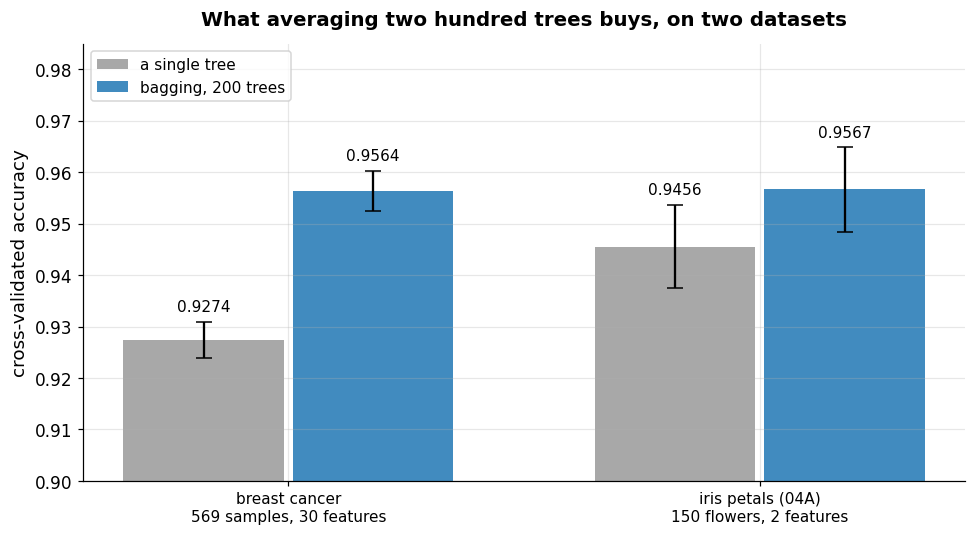

In [ ]:
subsets = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=0)

# The iris flowers of 04A, so the ensemble can be measured on the problem that motivated it.
# Colab starts each notebook fresh, so the loader of 01C 3.2 is repeated here.
try:
    iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
except Exception:
    from sklearn.datasets import load_iris
    bundled = load_iris(as_frame=True)
    iris = bundled.frame.rename(columns=lambda name: name.replace(" (cm)", "").replace(" ", "_"))
    iris["species"] = iris.pop("target").map(dict(enumerate(bundled.target_names)))

datasets = {"breast cancer\n569 samples, 30 features": (X, y),
            "iris petals (04A)\n150 flowers, 2 features": (iris[["petal_length", "petal_width"]],
                                                           iris["species"])}
models = [("a single tree", DecisionTreeClassifier(random_state=0)),
          ("bagging, 200 trees", BaggingClassifier(DecisionTreeClassifier(random_state=0),
                                                   n_estimators=200, random_state=0))]

compared = {}
for data_name, (features, target) in datasets.items():
    for model_name, model in models:
        compared[data_name, model_name] = cross_val_score(model, features, target,
                                                          cv=subsets, n_jobs=-1)

print(f"{'':>34}{'accuracy':>10}{'std error':>12}")
for data_name in datasets:
    print(f"{data_name.splitlines()[0]}:")
    for model_name, _ in models:
        s = compared[data_name, model_name]
        print(f"{model_name:>34}{s.mean():>10.4f}{s.std() / np.sqrt(len(s)):>12.4f}")
    gain = (compared[data_name, "bagging, 200 trees"].mean()
            - compared[data_name, "a single tree"].mean())
    error = np.sqrt(sum(compared[data_name, m].std() ** 2 / len(compared[data_name, m])
                        for m, _ in models))
    print(f"{'bought by averaging':>34}{100 * gain:>9.1f} pp   (+/- {100 * error:.1f})\n")

fig, axis = plt.subplots(figsize=(9, 5))
width, offsets = 0.34, {"a single tree": -0.18, "bagging, 200 trees": 0.18}
colours = {"a single tree": "0.6", "bagging, 200 trees": "tab:blue"}
for model_name, _ in models:
    spots = np.arange(len(datasets)) + offsets[model_name]
    middles = [compared[d, model_name].mean() for d in datasets]
    errors = [compared[d, model_name].std() / np.sqrt(len(compared[d, model_name]))
              for d in datasets]
    axis.bar(spots, middles, width, yerr=errors, capsize=5, label=model_name,
             color=colours[model_name], alpha=0.85)
    for spot, (middle, error) in zip(spots, zip(middles, errors)):
        axis.text(spot, middle + error + 0.002, f"{middle:.4f}", ha="center", fontsize=10)

axis.set_xticks(np.arange(len(datasets)))
axis.set_xticklabels(list(datasets), fontsize=10)
axis.set_ylim(0.90, 0.985)
axis.set_ylabel("cross-validated accuracy")
axis.set_title("What averaging two hundred trees buys, on two datasets")
axis.legend(loc="upper left")
plt.show()

Read the two pairs against each other, because they do not say the same thing.

On the **cancer** data, averaging removes just under three percentage points of error — from a
method that adds no new information whatsoever. Every tree saw the same 398 patients; the only thing
that changed was which parts of them each one saw. That is variance being divided, exactly as
`03B` §7 said it would be.

On the **iris** data it buys about a point, and the error bar covers that gap entirely. This is the
loop `04A` §11.3 opened, and it closes honestly rather than tidily: the three visibly different
partitions of the plane that `04A` ended on were *real*, and averaging them away turns out to be
worth much less there than here.

The reason is `03B` §5. The flowers the trees disagreed about are the ones where versicolor and
virginica genuinely overlap — `04A` §6 found three flowers sharing a petal coordinate and belonging
to two different species. That error is **irreducible**, and averaging cannot touch it. A tree on
iris is unstable in its *structure*, which `04A` showed, without being very wrong in its
*predictions*, which is what accuracy measures.

So bagging pays where the variance is, and iris did not have much to give. Thirty features and a few
hundred samples did — which is why this notebook changed datasets in section 1, and the bars are the
evidence for that choice rather than an assertion of it.

Two further things about bagging are worth saying plainly, because both are unusual.

**It cannot overfit in the number of trees.** Adding a tree to the average does not make the model
more flexible — each tree is fitted independently, and the average of more of them is a better
estimate of the same quantity. Section 5 shows the curve.

**It costs interpretability, completely.** `04A`'s tree could be drawn on a slide and read aloud.
Two hundred of them cannot. That is the trade, and it is not a small one: section 7 is about the
only thing you get back.

# 3. The trees are still too alike

Section 2's variance rule needs the $\hat{f}_b$ to be independent, and section 2's bootstrap
delivered independence **within** each resample. Those are not the same thing, and the gap between
them is this section.

**Given the training set, two resamples are independent of each other.** Each is its own set of
draws, and nothing links them. So averaging $B$ trees really does divide *that* source of variation
by $B$, all the way down to nothing.

**But the training set is itself one draw from a population of tumours, and every resample was built
from it.** As evidence about tumours — rather than about these 398 patients — the trees are
therefore *not* independent, and no way of resampling can make them so. Two bootstrap resamples
share about 63% of the distinct patients in each; they were never going to be unrelated.

With correlation $\rho$ between the estimates, the variance of the average is not $\sigma^2/B$ but

$$
\rho\,\sigma^2 \;+\; \frac{1 - \rho}{B}\,\sigma^2 ,
$$

and the two terms are exactly the two paragraphs above.

- $\dfrac{(1-\rho)\sigma^2}{B}$ is **the resampling**: which resamples you happened to draw. This
  is what averaging removes, and it vanishes as $B$ grows.
- $\rho\,\sigma^2$ is **the dataset**: which 398 patients you happened to have. No number of trees
  touches it.

So bagging does not manufacture $B$ datasets out of one. It removes the noise that the resampling
introduced and leaves the noise that was in the data to begin with. **The correlation, not the
number of trees, sets the floor.**

Which leaves the question that decides what to do next: what is $\rho$ made of? Two things, and
they are not equally stubborn. The trees share a **dataset**, and nothing in this notebook can
change that. They also share an **algorithm** — the same greedy search over the same thirty
features — and that is a choice rather than a fact. If one measurement is clearly the most
informative, almost every tree will ask about it first whatever its resample looked like, and the
trees end up sharing their top few questions.

The second part is attackable. Section 4 attacks it.

That the trees are alike is measurable. Below, every pair of trees in a bagged ensemble is compared
on the test set.

In [5]:
def disagreement(ensemble):
    """Mean fraction of test samples on which two trees of the ensemble differ."""
    ensemble.fit(X_train, y_train)
    votes = np.array([tree.predict(X_test.to_numpy()) for tree in ensemble.estimators_])
    pairs = [(votes[i] != votes[j]).mean()
             for i in range(len(votes)) for j in range(i + 1, len(votes))]
    return np.mean(pairs)

def first_questions(ensemble):
    """Which feature each tree of the ensemble asks about first."""
    asked = [tree.tree_.feature[0] for tree in ensemble.estimators_]
    return pd.Series([X.columns[a] for a in asked]).value_counts()

bagged = BaggingClassifier(DecisionTreeClassifier(random_state=0), n_estimators=30,
                           random_state=0)
print(f"bagging — mean pairwise disagreement: {disagreement(bagged):.4f}")
print("\nthe root question, over the 30 bagged trees:")
print(first_questions(bagged).head(4).to_string())

bagging — mean pairwise disagreement: 0.0886

the root question, over the 30 bagged trees:
worst perimeter         14
worst concave points     8
mean concave points      4
worst area               2


A handful of features take almost every root, and the trees disagree on fewer than one test sample
in ten. They are not thirty independent opinions.

They do not have to be near-identical for this to matter, and they are not: the correlation between
bagged trees is usually modest. But any $\rho$ above zero puts the floor $\rho\sigma^2$ under the
average, however many trees are added to it, so a modest correlation is quite enough to be worth
attacking.

So the question is how to force the trees apart *without* making any of them much worse.

# 4. The trick that makes it a forest

The answer is almost crude. **At every split, show the tree only a random subset of the features.**

Not a subset per tree — a fresh subset at *every node*. A tree that cannot see the strongest
feature at some node is forced to find the best of what it can see, which is usually a different,
correlated measurement. Across the ensemble the root questions spread out, the trees decorrelate,
and $\rho$ falls.

Each individual tree is slightly *worse* for being blindfolded. The average is better anyway,
because the term the blindfold attacks is the one that dominates.

That is the whole difference between bagging and a **random forest**, and in `scikit-learn` it is
the `max_features` argument. The default for classification is $\sqrt{p}$ — five of our thirty.

In [6]:
forest = RandomForestClassifier(n_estimators=30, random_state=0)
print(f"forest  — mean pairwise disagreement: {disagreement(forest):.4f}")
print(f"bagging — mean pairwise disagreement: {disagreement(bagged):.4f}")
print("\nthe root question, over the 30 forest trees:")
print(first_questions(forest).head(6).to_string())

forest  — mean pairwise disagreement: 0.0978


bagging — mean pairwise disagreement: 0.0886

the root question, over the 30 forest trees:
worst concave points    8
worst radius            5
mean concave points     3
area error              2
mean area               2
radius error            2


The root questions are spread over more features and the trees disagree more often — which is the
point, not a defect. Now the question is whether the extra disagreement is worth anything.


breast cancer   (p = 30)
 max_features   accuracy   std error
            1     0.9587      0.0037
            2     0.9572      0.0032
            5     0.9590      0.0033  <- sqrt(p), the default
            8     0.9587      0.0035
           15     0.9613      0.0041
           30     0.9572      0.0040  <- every feature: this is bagging

digits   (p = 64)
 max_features   accuracy   std error
            1     0.9664      0.0015
            4     0.9737      0.0015
            8     0.9738      0.0014  <- sqrt(p), the default
           16     0.9729      0.0014
           32     0.9687      0.0016
           64     0.9495      0.0024  <- every feature: this is bagging

synthetic   (p = 500)
 max_features   accuracy   std error
            3     0.6643      0.0077
           22     0.8393      0.0057  <- sqrt(p), the default
           50     0.8750      0.0061
          125     0.8887      0.0042
          500     0.8780      0.0050  <- every feature: this is bagging

synthetic p

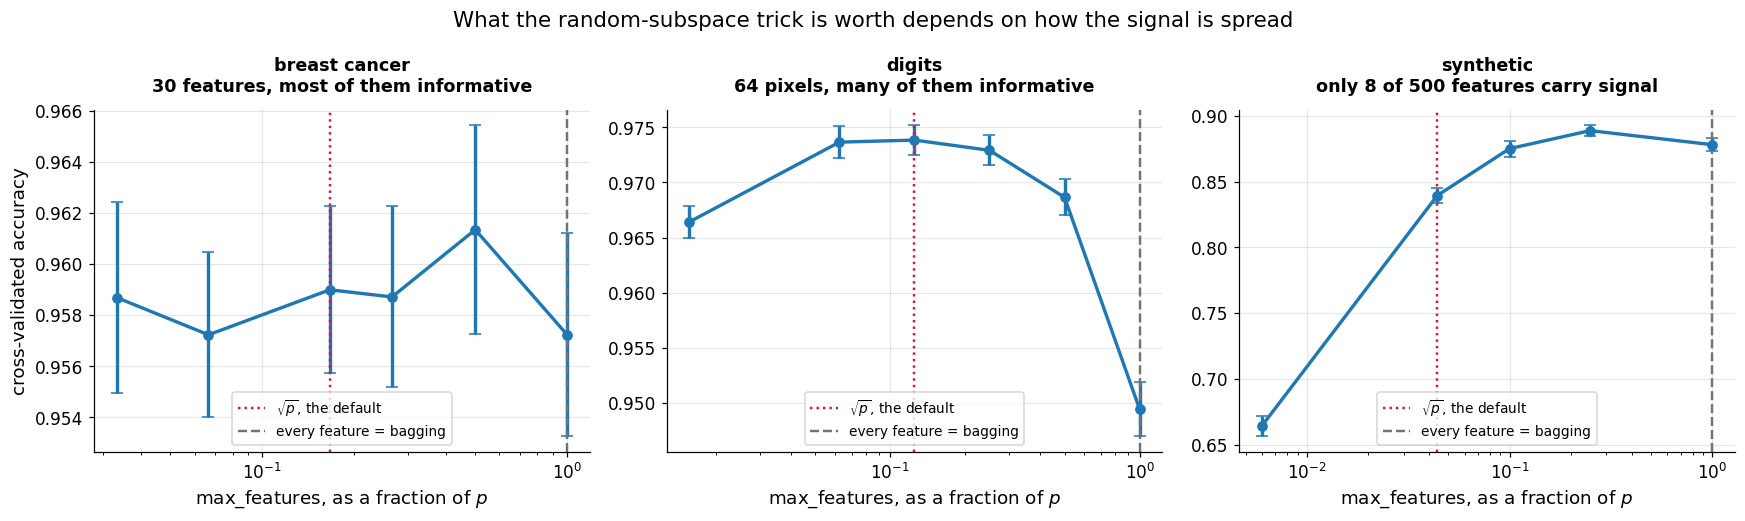

In [ ]:
# The same sweep on three datasets whose features are arranged very differently. The
# breast cancer column is the one section 3 has been working with; the other two are here
# to show how little that one column settles.
from sklearn.datasets import load_digits, make_classification

digits = load_digits()
scattered_X, scattered_y = make_classification(n_samples=500, n_features=500, n_informative=8,
                                               n_redundant=0, random_state=0)

problems = {
    "breast cancer\n30 features, most of them informative": ((X, y), [1, 2, 5, 8, 15, 30]),
    "digits\n64 pixels, many of them informative": ((digits.data, digits.target),
                                                     [1, 4, 8, 16, 32, 64]),
    "synthetic\nonly 8 of 500 features carry signal": ((scattered_X, scattered_y),
                                                        [3, 22, 50, 125, 500]),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, (name, ((features, target), choices)) in zip(axes, problems.items()):
    p_total, middles, errors = choices[-1], [], []
    print(f"\n{name.splitlines()[0]}   (p = {p_total})")
    print(f"{'max_features':>13}{'accuracy':>11}{'std error':>12}")
    for many in choices:
        result = cross_val_score(RandomForestClassifier(n_estimators=100, max_features=many,
                                                        random_state=0),
                                 features, target, cv=subsets, n_jobs=-1)
        middles.append(result.mean())
        errors.append(result.std() / np.sqrt(len(result)))
        note = ("  <- sqrt(p), the default" if many == int(np.sqrt(p_total))
                else "  <- every feature: this is bagging" if many == p_total else "")
        print(f"{many:>13}{middles[-1]:>11.4f}{errors[-1]:>12.4f}{note}")

    axis.errorbar([m / p_total for m in choices], middles, yerr=errors,
                  marker="o", linewidth=2.2, capsize=4)
    axis.axvline(int(np.sqrt(p_total)) / p_total, color="crimson", linestyle=":", linewidth=1.6,
                 label="$\\sqrt{p}$, the default")
    axis.axvline(1.0, color="0.45", linestyle="--", linewidth=1.6,
                 label="every feature = bagging")
    axis.set_xscale("log")
    axis.set_xlabel("max_features, as a fraction of $p$")
    axis.set_title(name, fontsize=11.5)
    axis.legend(loc="lower center", fontsize=9)

axes[0].set_ylabel("cross-validated accuracy")
fig.suptitle("What the random-subspace trick is worth depends on how the signal is spread",
             fontsize=14)
plt.show()

# Why the third panel has the shape it does: how often does a random draw of features
# contain none of the eight that carry signal?
from math import comb

print("\nsynthetic problem — chance that a random draw contains NONE of the 8 informative features")
for many in [3, 22, 50, 125]:
    print(f"   max_features = {many:>3}:  {comb(492, many) / comb(500, many):.0%}")

Take the left-hand panel first, since it is the dataset the notebook has been using. The trick buys
very little here — under two tenths of a percentage point, well inside error bars that section 2
told us to read as a lower bound anyway. On *this* problem, tuning `max_features` is not where your
afternoon should go.

**That is a fact about this dataset, and the other two panels are here to stop it being mistaken for
a fact about the method.**

On **digits** the same trick is worth about **two and a half percentage points** — nearly as much as
bagging itself bought on the cancer data, and many standard errors clear of it. Sixty-four pixels,
a great many carrying some signal, and a tree denied the strongest is pushed onto a genuinely
different one. This is the case the argument above describes, and the case the method was designed
for.

On the **synthetic** problem the default is not merely unhelpful, it is **wrong**: $\sqrt{p}$ loses
to plain bagging by nearly four points, and `max_features = 3` collapses to 0.66. Only 8 of the 500
features carry any signal, and the arithmetic printed under the figure accounts for the whole curve.
A random draw of 22 contains none of the 8 about **70%** of the time, so most splits are made on
noise; by 50 that is 43%, by 125 it is 10% — and 125 is where the curve peaks. **Blindfolding only
helps a tree that would otherwise have seen something worth seeing.**

So the shape is not fixed, and neither end is reliably the bad one. The left end fails when the
informative features are rare, because the subset misses them. The right end fails when they are
plentiful, because the trees then converge on the same questions and $\rho$ stops the average
improving. Which failure dominates is a property of the data, and so is where the optimum sits: nowhere in
particular on the left panel, where the curve is flat and every setting is within an error bar of
every other; exactly at $\sqrt{p}$ in the middle; and about six times $\sqrt{p}$ on the right.

> $\sqrt{p}$ for classification and $p/3$ for regression are conventions, not results. They encode a
> guess — that a random handful of features will usually contain a useful one — and the third panel
> is what happens when the guess is wrong. Leave `max_features` alone when $p$ is small and the
> features are mostly informative; search it when $p$ is large, or when you suspect the signal sits
> in a few columns out of many.

<div class="alert alert-success">
<b>Mini-exercise 1 — Where the trick earns its keep</b><br>
The effect above is small. It should be larger where one feature dominates.
<br><br>
1. Add a single very strong feature to this dataset — for instance <code>y</code> itself, corrupted
by flipping 15% of its values — and repeat the <code>max_features</code> sweep. Does the gap
between <code>max_features=5</code> and <code>max_features=30</code> widen?<br>
2. Measure the root question of thirty bagged trees on that modified data. How many take the
planted feature?<br>
3. From those two results, state in one sentence when you would expect the random-subspace trick to
matter and when you would not.
</div>

In [8]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. How many trees?

`04A` spent a section on depth because depth is a genuine bias–variance dial: too little underfits,
too much overfits, and the best value must be found. It is natural to expect `n_estimators` to
behave the same way.

It does not, and the reason is worth being precise about. Adding a tree does not give the model
more capacity to bend towards the training data — each tree is fitted independently of the others,
and averaging more of them simply estimates the same quantity more precisely. There is no value of
`n_estimators` that is *too many*; there is only a point past which more costs time and buys
nothing.

One distinction inside that, because it is easy to over-read. It is the **number of trees** that
cannot overfit. The forest they converge on still can: averaging fully grown trees can give a richer
model than the data support. That is why depth stays a dial to be chosen even though `n_estimators`
is not one.

The next cell scores forests of 1, 3, 10, 30, 100 and 300 trees.

1. Does the curve have a maximum, or does it flatten?
2. Where would you stop, and what would stop you?

**Think about your answer before running this cell.**

In [ ]:
sizes = [1, 3, 10, 30, 100, 300]
by_size = {n: cross_val_score(RandomForestClassifier(n_estimators=n, random_state=0),
                              X, y, cv=subsets, n_jobs=-1) for n in sizes}

print(f"{'trees':>7}{'accuracy':>11}{'std error':>12}")
for n, result in by_size.items():
    print(f"{n:>7}{result.mean():>11.4f}{result.std() / np.sqrt(len(result)):>12.4f}")

plt.figure(figsize=(8.5, 5))
plt.errorbar(sizes, [by_size[n].mean() for n in sizes],
             yerr=[by_size[n].std() / np.sqrt(len(by_size[n])) for n in sizes],
             marker="o", linewidth=2.2, capsize=4)
plt.xscale("log")
plt.xticks(sizes, [str(n) for n in sizes])
plt.xlabel("number of trees")
plt.ylabel("cross-validated accuracy")
plt.title("More trees never hurts; it just stops helping")
plt.show()

The curve climbs steeply and then flattens. It does not turn over, and no amount of patience will
make it turn over — that is the difference between this dial and `04A`'s depth.

So `n_estimators` is not chosen by cross-validation. It is chosen by how long you are willing to
wait: take enough trees that the curve has visibly flattened, then a few more. A hundred is a
reasonable habit and the `scikit-learn` default; three hundred costs three times as much and, here,
returns nothing you could measure.

> This is the one hyperparameter in the course where "more is better" is simply true. Enjoy it. The
> boosting of `04C` looks similar and is not: there, the number of rounds *is* a flexibility dial,
> and too many of them overfits in the ordinary way.

# 6. Validation that costs nothing

Bagging leaves something behind that is easy to overlook.

Each tree is fitted to $n$ observations drawn with replacement from $n$. Some are drawn more than
once, and some are not drawn at all. The probability that a particular observation misses a
particular bootstrap is

$$
\Bigl(1 - \tfrac{1}{n}\Bigr)^{n} \;\longrightarrow\; e^{-1} \approx 0.368 ,
$$

so **about a third of the training set is invisible to any given tree**. Those are its
**out-of-bag** observations, and for each of them that tree is an honest, untrained-on predictor.

Collect, for every observation, the votes of only the trees that did not see it, and you have a
validation score computed on data the ensemble never fitted — without setting anything aside and
without refitting anything. `oob_score=True` asks for it.

In [10]:
measured = RandomForestClassifier(n_estimators=300, oob_score=True,
                                  random_state=0).fit(X, y)
five_fold = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=0),
                            X, y, cv=5, n_jobs=-1)

print(f"out-of-bag score          : {measured.oob_score_:.4f}   (one fit)")
print(f"five-fold cross-validation: {five_fold.mean():.4f}   (five fits)")

fraction = [(1 - 1 / n) ** n for n in [10, 100, 1000, 10000]]
print(f"\nfraction of the data left out of one bootstrap, as n grows:")
print("   " + "   ".join(f"n={n}: {f:.3f}" for n, f in zip([10, 100, 1000, 10000], fraction)))
print(f"   the limit, 1/e: {np.exp(-1):.3f}")

out-of-bag score          : 0.9649   (one fit)
five-fold cross-validation: 0.9631   (five fits)

fraction of the data left out of one bootstrap, as n grows:
   n=10: 0.349   n=100: 0.366   n=1000: 0.368   n=10000: 0.368
   the limit, 1/e: 0.368


The two agree to within a couple of thousandths, and the out-of-bag figure came from a single fit
rather than five. On a large dataset that is the difference between minutes and an hour.

Two cautions, because it is not free of assumptions.

- It is available **only for bagged ensembles**. Nothing analogous exists for a single tree, or for
  the boosting of `04C`, because there is no bootstrap to be left out of.
- It estimates the performance of an ensemble of about $B/3$ trees, not of your $B$. With few trees
  it is pessimistic; by a few hundred the difference has vanished.

> If you are choosing a hyperparameter, `02C`'s rule still stands: the score that chose the model
> cannot also evaluate it. Out-of-bag is a cheap way to *choose*; a held-out test set is still how
> you report.

### Then why is cross-validation still the default for tuning?

Out-of-bag scoring *is* bootstrap validation, so it is fair to ask why the folds of `02C` remain the
usual tool for choosing a hyperparameter on anything that is not a bagged ensemble. Two reasons.

**Here it is free, and elsewhere it is not.** The resamples had to be drawn anyway to build the
forest, so their leftovers cost nothing. For a model that is not an ensemble, resampling validation
means fitting $B$ times with $B$ large, against $k$ times for a $k$-fold — and `scikit-learn`
supplies no bootstrap splitter to hand to `GridSearchCV`, only fold-based ones.

**And the classical bootstrap error estimators have a failure mode that folds do not.** A model
fitted to a resample sees only about two thirds of the distinct rows, so its error comes out
pessimistic; the standard remedy is to blend in the error measured on the training rows themselves.
That blend is sound until the model can *memorise* its training data — an unpruned tree can — at
which point the training term is zero and the corrected estimate turns wildly optimistic. Broad
comparisons across many datasets have found exactly that pattern: low variance, and occasionally
very large bias.

The out-of-bag score above applies no such correction, which is what makes it trustworthy here. It
is also why it is not a general replacement for a fold.

# 7. Feature importance, and the three ways it lies

`04A` gave up interpretability the moment it went from one tree to two hundred. What comes back in
its place is a ranking: for each feature, how much did the ensemble rely on it?

The default in `scikit-learn` is **impurity importance**, sometimes called Gini importance. Every
split on a feature removed some impurity, weighted by how many samples reached it; add that up over
every node of every tree, normalise, and you have a number per feature. It is free, because the
tree recorded everything it needs while it was being built.

It is also, in three specific ways, misleading.

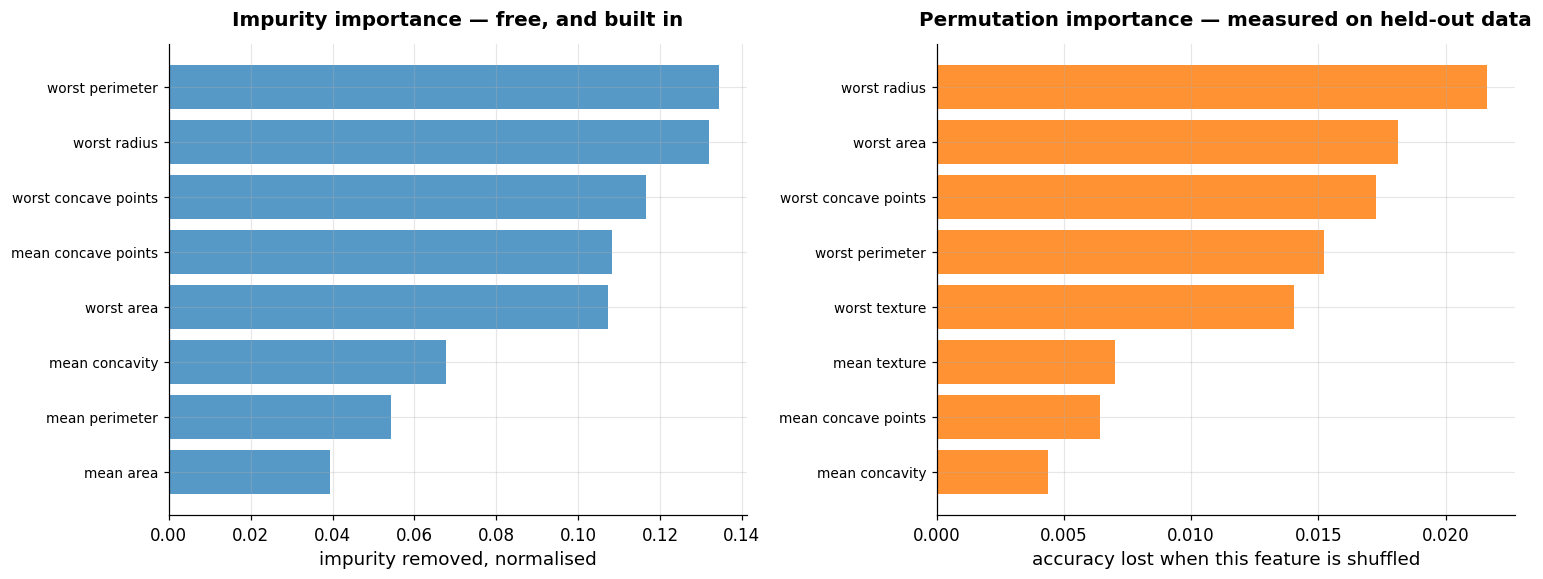

correlation between the top two impurity features
   worst perimeter and worst radius: 0.994


In [11]:
planted = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_train, y_train)
by_impurity = pd.Series(planted.feature_importances_, index=X.columns).sort_values(ascending=False)

shuffled = permutation_importance(planted, X_test, y_test, n_repeats=20,
                                  random_state=0, n_jobs=-1)
by_permutation = pd.Series(shuffled.importances_mean, index=X.columns).sort_values(ascending=False)

top = 8
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.4))
left.barh(range(top), by_impurity.head(top).to_numpy()[::-1], color="tab:blue", alpha=0.75)
left.set_yticks(range(top))
left.set_yticklabels(by_impurity.head(top).index[::-1], fontsize=9)
left.set_xlabel("impurity removed, normalised")
left.set_title("Impurity importance — free, and built in")

right.barh(range(top), by_permutation.head(top).to_numpy()[::-1], color="tab:orange", alpha=0.85)
right.set_yticks(range(top))
right.set_yticklabels(by_permutation.head(top).index[::-1], fontsize=9)
right.set_xlabel("accuracy lost when this feature is shuffled")
right.set_title("Permutation importance — measured on held-out data")
plt.show()

pair = by_impurity.index[:2]
print(f"correlation between the top two impurity features")
print(f"   {pair[0]} and {pair[1]}: {X[pair[0]].corr(X[pair[1]]):.3f}")

The two rankings do not agree, and the disagreement is the lesson.

**It rewards features that were *available*, not features that are *needed*.** The top two by
impurity correlate at 0.99 — they are very nearly the same measurement written twice. The forest
had to pick one at each split, so the credit was divided between them, and a third measurement that
carries the same information would divide it three ways. Read either one as "this measurement
matters twice as much as that one" and you are reading an artefact of how many near-copies of it
happen to be in the table.

**It is computed on the training data.** A feature the ensemble used to memorise noise scores just
as highly as one it used to generalise. Impurity importance cannot tell the difference, because it
never looks at data the model has not seen.

**It is biased towards features with many possible split points.** A continuous measurement offers
hundreds of thresholds to choose from and will beat a binary flag on impurity even when the flag is
more informative — the continuous one simply had more chances to look good.

**Permutation importance** answers a different and usually better question: shuffle one column of
the *held-out* data, so that feature becomes noise while everything else stays as it was, and
measure how much accuracy is lost. It is computed on data the model never saw, it asks about the
fitted model's actual reliance, and it applies to any model at all, not just trees.

> It inherits the correlation problem, and in a worse form. Shuffle one of two near-identical
> features and the model simply reads the other, so *both* score near zero and the pair looks
> unimportant. When features come in correlated groups, permute the **group**.

<div class="alert alert-success">
<b>Mini-exercise 2 — Importance of a column that means nothing</b><br>
1. Add a column of pure noise (<code>rng.normal</code>, one value per sample) to the training data
and refit the forest. Where does the noise column rank by impurity importance? Where by
permutation importance?<br>
2. Add instead a column of random integers between 0 and 500 — still meaningless, but with hundreds
of possible split points. Does its impurity importance rise?<br>
3. Take the two most correlated real features and shuffle them <b>together</b> rather than
separately. How does their joint permutation importance compare with the sum of their individual
ones?<br>
4. Which of the two measures would you report in a paper, and what would you say about it?
</div>

In [12]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 8. What a forest costs

Accuracy is not the only axis, and a forest is worse than a single tree on several of the others.

**Interpretability.** The largest cost and the least recoverable. `04A`'s tree was a flowchart you
could read to a collaborator; a forest is three hundred of them voting. Feature importance is a
summary of that, not a substitute for it.

**Prediction time and size.** Three hundred trees take three hundred times the memory and roughly
three hundred times the arithmetic per prediction. Usually irrelevant; occasionally decisive.

**It still cannot extrapolate.** Every tree in the forest is piecewise constant outside the training
range, so their average is too. `04A` §10's warning survives the ensemble unchanged, and averaging
does nothing about it.

**Its probabilities are better behaved than a tree's, but they are not calibrated.** A single tree
reports the class proportions of one leaf and so is wildly overconfident — often exactly 0 or 1. A
forest reports the fraction of trees voting each way, which `03A` §8 predicts will be pulled in from
the extremes, since it takes unanimity to reach 0 or 1. Better is not the same as right: check it
with `03A` §8's calibration curve before treating a forest's output as a probability.

      one tree: mean |predicted - observed| = 0.091
                  says 0.00,  actually benign 0.13   (221 samples)
                  says 1.00,  actually benign 0.95   (348 samples)
 forest of 300: mean |predicted - observed| = 0.065
                  says 0.01,  actually benign 0.00   (151 samples)
                  says 0.13,  actually benign 0.00   (23 samples)
                  says 0.85,  actually benign 0.96   (26 samples)
                  says 0.98,  actually benign 0.99   (296 samples)
      one tree: 100.0 % of predictions are exactly 0 or 1
 forest of 300:  29.0 % of predictions are exactly 0 or 1


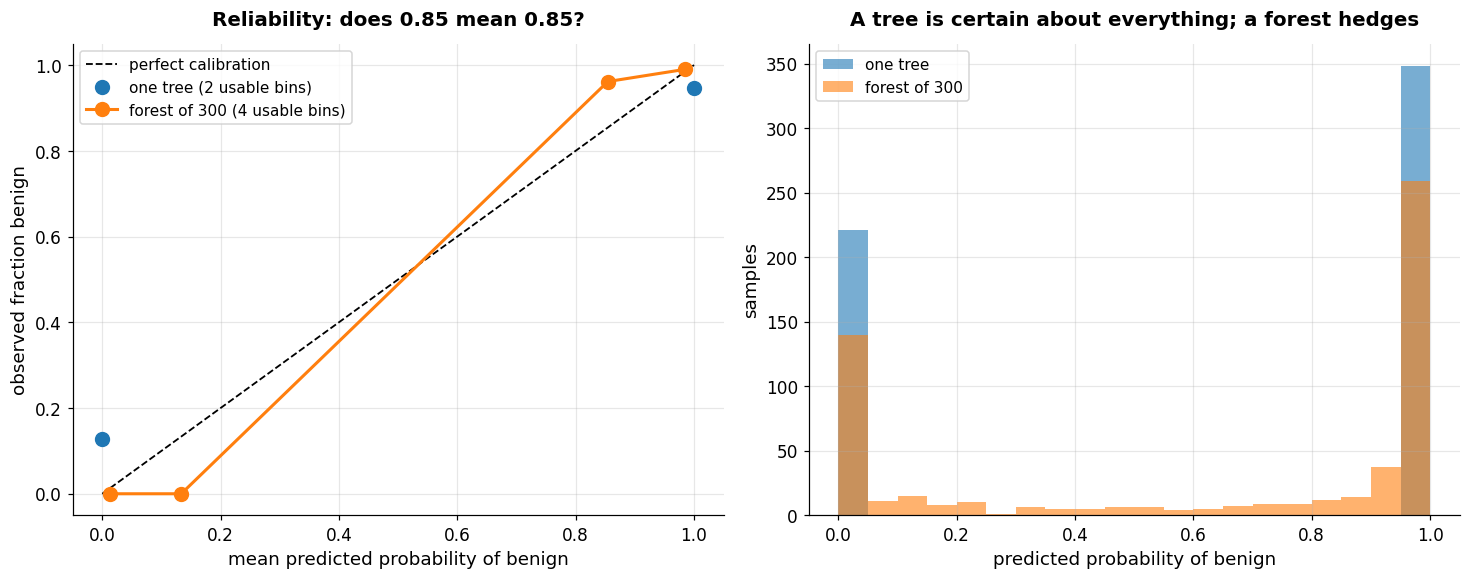

In [ ]:
# Out-of-fold probabilities for every sample, so calibration is judged on data each model
# did not see. cross_val_predict is cross_val_score's sibling: same folds, but it returns the
# held-out predictions themselves rather than a score.
probabilities = {}
for name, model in [("one tree", DecisionTreeClassifier(random_state=0)),
                    ("forest of 300", RandomForestClassifier(n_estimators=300, random_state=0))]:
    probabilities[name] = cross_val_predict(model, X, y, cv=5,
                                            method="predict_proba", n_jobs=-1)[:, 1]

def reliability(true_labels, predicted, n_bins=10, floor=20):
    """Mean predicted probability against observed frequency — 03A section 8's helper."""
    edges = np.linspace(0, 1, n_bins + 1)
    which_bin = np.digitize(predicted, edges[1:-1])
    rows = [(predicted[inside].mean(), true_labels[inside].mean(), inside.sum())
            for inside in (which_bin == b for b in range(n_bins)) if inside.sum() >= floor]
    return np.array(rows)

fig, (curve, spread) = plt.subplots(1, 2, figsize=(13.5, 5.4))
curve.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="perfect calibration")
for name, colour, style in [("one tree", "tab:blue", "none"),
                            ("forest of 300", "tab:orange", "-")]:
    bins = reliability(y.to_numpy(), probabilities[name])
    curve.plot(bins[:, 0], bins[:, 1], marker="o", markersize=9, linestyle=style,
               color=colour, linewidth=2, label=f"{name} ({len(bins)} usable bins)")
    print(f"{name:>14}: mean |predicted - observed| = "
          f"{np.abs(bins[:, 0] - bins[:, 1]).mean():.3f}")
    for predicted, observed, count in bins:
        print(f"                  says {predicted:.2f},  actually benign {observed:.2f}"
              f"   ({int(count)} samples)")

curve.set_xlabel("mean predicted probability of benign")
curve.set_ylabel("observed fraction benign")
curve.set_title("Reliability: does 0.85 mean 0.85?")
curve.legend(loc="upper left")

for name, colour in [("one tree", "tab:blue"), ("forest of 300", "tab:orange")]:
    spread.hist(probabilities[name], bins=20, alpha=0.6, label=name, color=colour)
spread.set_xlabel("predicted probability of benign")
spread.set_ylabel("samples")
spread.set_title("A tree is certain about everything; a forest hedges")
spread.legend()
plt.show()

for name, predicted in probabilities.items():
    print(f"{name:>14}: {100 * ((predicted == 0) | (predicted == 1)).mean():5.1f} % of "
          f"predictions are exactly 0 or 1")

Both panels, right to left.

The **single tree** puts every prediction at 0 or 1, because a leaf is usually pure and a pure leaf
reports certainty. That is why its reliability curve is two isolated points and not a curve at all —
there are no intermediate probabilities to bin. Both points miss the diagonal: it says 0.00 for
samples that are benign 13% of the time, and 1.00 for samples that are benign 95% of the time. Its
mean miss is about nine percentage points.

The **forest** spreads out, because reaching 1.0 takes unanimity among three hundred trees and on
the difficult samples they do not agree. That gives four usable bins instead of two, and a mean miss
of about six points.

Better — and wrong in a specific, predictable place rather than wrong all over. Look at the bin
where the forest says 0.85: those samples are actually benign 96% of the time. The forest is
**under-confident at the extremes**, because reaching 0 or 1 takes unanimity, and the few trees that
dissent pull the vote share inwards. `03A` §8 predicted exactly this for an averaged ensemble.

It is worth being precise about the size of the complaint. Averaged tree ensembles are, across model
families, among the **better**-calibrated things you can fit — better than a single tree by a wide
margin, and better than several methods `03A` §8 also listed. The fault is local: they handle the
middle of the range well and cannot reach its ends.

Two consequences. The spread is what makes a forest's output usable as a *ranking*, which is why
`03A` §7's ROC and average precision mean something for a forest and very little for a single tree.
But a vote share is not a probability, so if you intend to act on the number — set a threshold from
an expected yield, or combine it with a cost — calibrate it first. `03A` §8's
`CalibratedClassifierCV` is the tool.

# 9. Common pitfalls

**Reporting a single tree's structure from inside a forest.** There is no representative tree. The
ensemble's answer is the average; no member of it is the model.

**Tuning `n_estimators` by cross-validation.** Section 5: the curve does not turn over, so the
search will always tell you to use more. Choose it by patience, not by score.

**Reading impurity importance as scientific evidence.** Section 7, all three ways. If a ranking is
going into a paper, use permutation importance on held-out data, permute correlated features as a
group, and say which you used.

**Expecting the forest to fix extrapolation.** It cannot. Averaging piecewise-constant functions
gives a piecewise-constant function.

**Using out-of-bag as both selector and report.** `02C` §5's rule does not lapse because the score
was cheap.

**Forgetting that a forest of stumps is not a forest.** The variance reduction argument assumes the
members are low-bias. Depth-limit the trees hard enough and you have averaged a set of underfitted
models, which averaging cannot repair.

# 10. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — Bagging something that is not a tree</b><br>
Section 2's argument had two conditions: the members must be <em>low-bias</em>, and averaging must
have variance to divide. A tree meets both. Two other models do not.
<br><br>
1. Bag 200 <code>LogisticRegression</code> models on the cancer data and compare with a single one,
using the same <code>subsets</code>. How much does averaging buy?<br>
2. Bag 200 decision stumps — <code>DecisionTreeClassifier(max_depth=1)</code> — and compare with a
single stump.<br>
3. Each fails for a different reason. Say which condition each one breaks.<br>
4. Section 9's last pitfall claims a forest of stumps cannot be repaired by averaging. Does your
result support it?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Out-of-bag against a held-out set</b><br>
Section 6 claimed the out-of-bag score is pessimistic when there are few trees, and that the gap
vanishes by a few hundred.
<br><br>
1. Split the cancer data into training and test halves.<br>
2. For <code>n_estimators</code> of 5, 10, 25, 50, 100, 200 and 400, fit a forest on the training
half with <code>oob_score=True</code> and record both the out-of-bag score and the test accuracy.<br>
3. Plot the two against the number of trees on one pair of axes.<br>
4. At roughly how many trees do they meet? Does the out-of-bag score approach from below, as
section 6 predicts?
<br><br>
<b>To check yourself:</b> at five trees the two should differ by several percentage points, and by
four hundred by well under one.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — A forest on a regression problem</b><br>
Everything in this notebook was classification. Section 2 said the regressor differs only in
averaging rather than voting, so put that to the test on the diabetes data of <code>03C</code>.
<br><br>
1. Load it with <code>load_diabetes</code> and cross-validate a <code>RandomForestRegressor</code>,
scoring with <code>neg_mean_squared_error</code>.<br>
2. Compare against the ridge model of <code>03C</code> §5 and against a single
<code>DecisionTreeRegressor</code>.<br>
3. Does the forest beat the single tree by more or less than it did on the cancer data? Section 2's
last figure suggests what to look for.<br>
4. <code>max_features</code> defaults to $p/3$ for regression rather than $\sqrt{p}$. Sweep it from
1 to 10 and say whether the default is defensible here.<br>
5. Ridge is a linear model and the forest is not. On this dataset, which wins, and what does that
tell you about the shape of the relationship?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- A single tree is low-bias and high-variance. **Bagging** — bootstrap the training set, fit a tree
  to each resample, aggregate the answers (vote for a classifier, average for a regressor) — divides
  the variance without touching the bias, and on the cancer data removes just under three percentage
  points of error.
- **It pays only where the variance is.** The same comparison on `04A`'s iris petals bought about a
  point, inside the error bars, because the flowers the trees disagreed about are the ones where two
  species genuinely overlap. Averaging divides variance; it cannot touch `03B` §5's irreducible
  error.
- A **bootstrap resample** imitates re-running the experiment: $n$ draws, independently, from the
  sample standing in for the population. *With replacement* is what makes the draws independent —
  without it, $n$ draws return the same dataset and estimate a spread of exactly zero. Folds are not
  a substitute: they give only $k$ members, each trained on less data and constrained by the
  partition.
- Bagged trees are **correlated**, because they all run the same greedy search on the same features.
  Correlation $\rho$ leaves a floor of $\rho\sigma^2$ that no number of trees can get below.
- A **random forest** is bagging plus one trick: a fresh random subset of features at every split,
  set by `max_features`. It decorrelates the trees at the cost of making each slightly worse.
- **What that trick is worth is a property of the data, not of the method.** Almost nothing on the
  cancer data; about two and a half points on digits; and *negative* where only 8 of 500 features
  carry signal, because a random draw of $\sqrt{p}$ of them misses all eight 70% of the time.
  Treat `max_features` as a hyperparameter whenever $p$ is large or the signal may be concentrated
  in a few columns.
- **More trees never overfits.** `n_estimators` is chosen by patience; depth is chosen by
  cross-validation. Do not confuse the two dials.
- **Out-of-bag** scoring is validation from the samples each tree did not see — about $1/e$ of them
  — for the price of one fit.
- **Feature importance misleads in three ways**: it splits credit between correlated features, it
  is computed on training data, and it favours features with more split points. Permutation
  importance on held-out data fixes two of the three; permuting correlated features as a group
  fixes the first.
- A forest's probabilities are **much better than a tree's, and specifically weak at the extremes**:
  reaching 0 or 1 takes unanimity, so a vote share is pulled inwards and the forest is
  under-confident there. Sound to rank with; check the reliability curve before acting on the
  numbers themselves.

# Optional preparation for the next notebook

Before `04C`, students should be comfortable with:

- what bagging averages, and why the members must be low-bias for it to work;
- reading a cross-validated score with its standard error, and not over-reading a difference
  smaller than one;
- `04A`'s trees, especially depth as a flexibility dial.

`04C` builds an ensemble the other way round. A forest grows many strong trees independently and
averages away their variance; **gradient boosting** grows many *deliberately weak* trees in
sequence, each one fitted to what the ones before it got wrong. The members are high-bias by design
and the ensemble reduces bias rather than variance — which is why the number of rounds is a
flexibility dial that overfits, exactly the dial section 5 said `n_estimators` was not.